In [ ]:
# Clone just the code again (fresh Colab session = fresh VM, nothing persists)
!git clone --filter=blob:none --sparse https://github.com/hackysoham/ASTRA.git
%cd ASTRA
!git sparse-checkout set src notebooks report tests

from google.colab import drive
drive.mount('/content/drive')
DRIVE_FOLDER = '/content/drive/MyDrive/nssc2026'

fatal: destination path 'ASTRA' already exists and is not an empty directory.
/content/ASTRA
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q {DRIVE_FOLDER}/phase1_all_outputs.zip -d /content/phase1_outputs
!ls /content/phase1_outputs  # confirm models/, plots/, latents/ are all there

replace /content/phase1_outputs/latent_vectors/latents_v1.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: latent_vectors	models	plots


# Phase 2: Isolation Forest Novelty Engine (20 Marks)

**Team Astra** | NSSC 2026 | IIT Kharagpur  
**Lead:**

---

## Objectives
1. Feed 1D latent vectors into an Isolation Forest for Novelty Scoring
2. Invert native IF scores so that **higher = more anomalous**
3. Fuse metadata (sun_angle, season) with latent embeddings
4. Apply **three independent** statistical thresholding methods:
   - Generalized Pareto Distribution (Extreme Value Theory)
   - KDE Knee Detection
   - Median Absolute Deviation (Modified Z-score)
5. Determine anomalies via consensus voting (≥2 of 3 methods)

### Key Constraints
- **No arbitrary fixed-count cutoffs**
- **No contamination parameter** to decide anomaly count
- **Mathematical justification** required for threshold boundary

In [ ]:
# ─── System Setup ─────────────────────────────────────────────────────
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

IMAGE_DIR = os.path.join(PROJECT_ROOT, 'data', 'images')
METADATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'source_image_metadata.csv')
LATENT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'latent_vectors')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'plots')
SCORES_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'scores')

In [ ]:
LATENT_DIR = '/content/phase1_outputs/latent_vectors'
PLOTS_DIR = '/content/phase1_outputs/plots'
METADATA_PATH = f'{DRIVE_FOLDER}/source_image_metadata.csv'
CROP_INDEX_PATH = f'{DRIVE_FOLDER}/crop_metadata_index.csv'   # keep this handy, see point 3
SCORES_DIR = '/content/outputs/scores'
os.makedirs(SCORES_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print('LATENT_DIR:', LATENT_DIR, '| exists:', os.path.exists(LATENT_DIR))
print('PLOTS_DIR:', PLOTS_DIR, '| exists:', os.path.exists(PLOTS_DIR))

LATENT_DIR: /content/phase1_outputs/latent_vectors | exists: True
PLOTS_DIR: /content/phase1_outputs/plots | exists: True


In [ ]:
# ─── Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import set_seed
from src.latent_utils import load_latents, plot_tsne, plot_umap
from src.isolation_forest import (
    build_features,
    run_isolation_forest,
    compute_threshold_gpd,
    compute_threshold_kde_knee,
    compute_threshold_mad,
    consensus_threshold,
    plot_score_distribution,
    save_scores,
)

set_seed(42)
print('Phase 2 imports ready.')

Phase 2 imports ready.


In [ ]:
v5_check, _ = load_latents(save_dir=LATENT_DIR, version='v5')
print('Any NaN in v5 latents:', np.isnan(v5_check).any())
print('v5 latent range:', v5_check.min(), v5_check.max())

[Latent] Loaded 10422 vectors of dim 256
Any NaN in v5 latents: False
v5 latent range: -6.30141e-40 6.29283e-40


## 2.1 Load Latent Vectors

Load the latent vectors extracted in Phase 1 from the best model version.

In [ ]:
# Load latent vectors from the best version (v5)
# Also load v1 for comparison
BEST_VERSION = 'v5'

latents, filenames = load_latents(save_dir=LATENT_DIR, version=BEST_VERSION)
print(f'Latent vectors shape: {latents.shape}')
print(f'Number of images: {len(filenames)}')
print(f'Latent dimension: {latents.shape[1]}')

[Latent] Loaded 10422 vectors of dim 256
Latent vectors shape: (10422, 256)
Number of images: 10422
Latent dimension: 256


## 2.2 Metadata Fusion

Concatenate the 1D image embedding with an encoded metadata vector:
- Normalized `sun_angle` (min-max → [0, 1])
- Cyclically encoded `season` (sin, cos)

In [ ]:
crop_index = pd.read_csv(CROP_INDEX_PATH)          # filename, source_image_id
source_meta = pd.read_csv(METADATA_PATH)            # source_image_id, latitude, longitude, sun_angle, season, resolution

merged_meta = crop_index.merge(source_meta, on='source_image_id', how='left')
print('Merged shape:', merged_meta.shape)
print('Any unmatched (NaN latitude)?', merged_meta['latitude'].isna().sum())

MERGED_METADATA_PATH = '/content/merged_crop_metadata.csv'
merged_meta.to_csv(MERGED_METADATA_PATH, index=False)
merged_meta.head()

Merged shape: (10422, 7)
Any unmatched (NaN latitude)? 0


,filename,source_image_id,latitude,longitude,sun_angle,season,resolution
0,sample_00001.jpg,SRC_042,10.0,180.0,36.924310,N-spring,0.50
1,sample_00002.jpg,SRC_022,20.0,180.0,41.513642,N-spring,0.25
2,sample_00003.jpg,SRC_074,0.0,180.0,50.254590,N-spring,0.50
3,sample_00004.jpg,SRC_091,-40.0,180.0,72.511342,N-summer,0.50
4,sample_00005.jpg,SRC_108,-40.0,180.0,68.856247,N-summer,0.50


In [ ]:
features, info_df = build_features(
    latents=latents,
    filenames=filenames,
    metadata_path=MERGED_METADATA_PATH,   # <- changed from METADATA_PATH
)

print(f'\nCombined feature shape: {features.shape}')
print(f'Info DataFrame columns: {list(info_df.columns)}')
info_df.head()

[Metadata] Loaded 10422 rows from /content/merged_crop_metadata.csv
[Metadata] Columns: ['filename', 'source_image_id', 'latitude', 'longitude', 'sun_angle', 'season', 'resolution']
[Fusion] Matched 0/10422 images to metadata
[Fusion] sun_angle range: [nan, nan]
[Fusion] season encoded cyclically (sin, cos)
[Fusion] Combined feature dim: 256 (latent) + 3 (metadata) = 259

Combined feature shape: (10422, 259)
Info DataFrame columns: ['filename_x', 'source_image_id', 'filename_y', 'latitude', 'longitude', 'sun_angle', 'season', 'resolution']


/usr/local/lib/python3.13/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


,filename_x,source_image_id,filename_y,latitude,longitude,sun_angle,season,resolution
0,sample_00001.jpg,sample_00001,NaN,NaN,NaN,NaN,NaN,NaN
1,sample_00002.jpg,sample_00002,NaN,NaN,NaN,NaN,NaN,NaN
2,sample_00003.jpg,sample_00003,NaN,NaN,NaN,NaN,NaN,NaN
3,sample_00004.jpg,sample_00004,NaN,NaN,NaN,NaN,NaN,NaN
4,sample_00005.jpg,sample_00005,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import inspect
print(inspect.getsource(build_features))

def build_features(
    latents: np.ndarray,
    filenames: List[str],
    metadata_path: str = None,
) -> Tuple[np.ndarray, pd.DataFrame]:
    """Build combined feature vectors by fusing latent embeddings with metadata.
    
    If metadata is available, concatenates:
        [latent_vector | normalized_sun_angle | encoded_season]
    Otherwise, uses only the latent vectors.
    
    Args:
        latents: Numpy array of shape (N, latent_dim).
        filenames: List of N filenames.
        metadata_path: Optional path to source_image_metadata.csv.
    
    Returns:
        Tuple of (features, info_df) where:
            features: Combined feature array of shape (N, D)
            info_df: DataFrame with filename, source_id, and metadata columns
    """
    # Create base info DataFrame
    info_df = pd.DataFrame({"filename": filenames})
    info_df["source_image_id"] = info_df["filename"].apply(extract_source_id)

    if metadata_path is not None and Path(metadata_path).exists():
    

In [ ]:
import src.isolation_forest as isolation_forest_module
import inspect
print(inspect.getsource(isolation_forest_module.extract_source_id))

def extract_source_id(filename: str) -> str:
    """Extract source_image_id from an image filename using the real
    crop_metadata_index.csv mapping (filename parsing was unreliable —
    dataset filenames like 'sample_00001.jpg' carry no embeddable source
    ID, unlike the original assumed 'ESP_..._crop_...' convention).
    """
    global _CROP_INDEX_LOOKUP
    if _CROP_INDEX_LOOKUP is None:
        import os
        crop_index_path = os.environ.get("CROP_INDEX_PATH")
        if crop_index_path and Path(crop_index_path).exists():
            df = pd.read_csv(crop_index_path)
            _CROP_INDEX_LOOKUP = dict(zip(df["filename"], df["source_image_id"]))
        else:
            _CROP_INDEX_LOOKUP = {}
    return _CROP_INDEX_LOOKUP.get(filename, Path(filename).stem)



In [ ]:
with open('/content/ASTRA/src/isolation_forest.py', 'r') as f:
    content = f.read()

old_func = '''def extract_source_id(filename: str) -> str:
    """Extract source_image_id from an image filename.

    Attempts to parse the source ID from the filename by removing
    the file extension and any crop-index suffixes.

    Args:
        filename: Image filename (e.g., 'ESP_012345_1234_crop_001.png').

    Returns:
        Source image ID string.
    """
    # Remove extension
    name = Path(filename).stem
    # Try to extract the base source ID (before '_crop' or similar suffix)
    # Adjust this parsing logic based on actual filename conventions
    parts = name.split("_crop")
    return parts[0] if len(parts) > 1 else name'''

new_func = '''_CROP_INDEX_LOOKUP = None

def extract_source_id(filename: str) -> str:
    """Extract source_image_id from an image filename using the real
    crop_metadata_index.csv mapping (filename parsing was unreliable —
    dataset filenames like 'sample_00001.jpg' carry no embeddable source
    ID, unlike the original assumed 'ESP_..._crop_...' convention).
    """
    global _CROP_INDEX_LOOKUP
    if _CROP_INDEX_LOOKUP is None:
        import os
        crop_index_path = os.environ.get("CROP_INDEX_PATH")
        if crop_index_path and Path(crop_index_path).exists():
            df = pd.read_csv(crop_index_path)
            _CROP_INDEX_LOOKUP = dict(zip(df["filename"], df["source_image_id"]))
        else:
            _CROP_INDEX_LOOKUP = {}
    return _CROP_INDEX_LOOKUP.get(filename, Path(filename).stem)'''

if old_func not in content:
    print("WARNING: exact text not found — paste the full isolation_forest.py so I can locate it precisely")
else:
    content = content.replace(old_func, new_func)
    with open('/content/ASTRA/src/isolation_forest.py', 'w') as f:
        f.write(content)
    print("Patched extract_source_id to use the real crop index mapping")

In [ ]:
import os
os.environ["CROP_INDEX_PATH"] = CROP_INDEX_PATH   # the Drive path you defined earlier

import importlib
importlib.reload(isolation_forest_module)
from src.isolation_forest import (
    build_features, run_isolation_forest, compute_threshold_gpd,
    compute_threshold_kde_knee, compute_threshold_mad,
    consensus_threshold, plot_score_distribution, save_scores,
)
print("Reloaded isolation_forest module")

Reloaded isolation_forest module


In [ ]:
features, info_df = build_features(
    latents=latents,
    filenames=filenames,
    metadata_path=METADATA_PATH,
)
print(f'\nCombined feature shape: {features.shape}')
info_df.head()

[Metadata] Loaded 172 rows from /content/drive/MyDrive/nssc2026/source_image_metadata.csv
[Metadata] Columns: ['source_image_id', 'latitude', 'longitude', 'sun_angle', 'season', 'resolution']
[Fusion] Matched 10422/10422 images to metadata
[Fusion] sun_angle range: [32.1, 85.7]
[Fusion] season encoded cyclically (sin, cos)
[Fusion] Combined feature dim: 256 (latent) + 3 (metadata) = 259

Combined feature shape: (10422, 259)


,filename,source_image_id,latitude,longitude,sun_angle,season,resolution
0,sample_00001.jpg,SRC_042,10.0,180.0,36.924310,N-spring,0.50
1,sample_00002.jpg,SRC_022,20.0,180.0,41.513642,N-spring,0.25
2,sample_00003.jpg,SRC_074,0.0,180.0,50.254590,N-spring,0.50
3,sample_00004.jpg,SRC_091,-40.0,180.0,72.511342,N-summer,0.50
4,sample_00005.jpg,SRC_108,-40.0,180.0,68.856247,N-summer,0.50


## 2.3 Isolation Forest Scoring

Fit Isolation Forest on the fused feature vectors. The native `decision_function` scores are **inverted** so that higher score = greater anomalousness.

In [ ]:
# Run Isolation Forest
novelty_scores = run_isolation_forest(
    features,
    n_estimators=300,
    max_samples='auto',
    random_state=42,
)

print(f'\nScore Statistics:')
print(f'  Min:    {novelty_scores.min():.6f}')
print(f'  Max:    {novelty_scores.max():.6f}')
print(f'  Mean:   {novelty_scores.mean():.6f}')
print(f'  Median: {np.median(novelty_scores):.6f}')
print(f'  Std:    {novelty_scores.std():.6f}')

[IF] Fitting Isolation Forest (n_estimators=300)...
[IF] Score range: [-0.0525, 0.2510] (mean=0.0024, std=0.0497)

Score Statistics:
  Min:    -0.052454
  Max:    0.250972
  Mean:   0.002425
  Median: -0.008022
  Std:    0.049697


In [ ]:
# Sanity check the sign convention: cross-reference against reconstruction error.
# The crop with the HIGHEST novelty score should also have unusually poor reconstruction —
# if it's the LOWEST score instead, the sign is flipped somewhere.
top_idx = np.argmax(novelty_scores)
bottom_idx = np.argmin(novelty_scores)
print('Highest-scoring (should look anomalous):', filenames[top_idx], novelty_scores[top_idx])
print('Lowest-scoring (should look ordinary):', filenames[bottom_idx], novelty_scores[bottom_idx])

Highest-scoring (should look anomalous): sample_02889.jpg 0.2509718223501626
Lowest-scoring (should look ordinary): sample_00031.jpg -0.05245445100015833


## 2.4 Statistical Thresholding

### Method 1: Generalized Pareto Distribution (Extreme Value Theory)

Under the **Pickands–Balkema–De Haan theorem**, exceedances over a sufficiently high threshold follow a Generalized Pareto Distribution. We fit GPD to scores above the 90th percentile and compute the quantile at p < 0.01.

In [ ]:
# Method 1: GPD (Extreme Value Theory)
threshold_gpd, info_gpd = compute_threshold_gpd(
    novelty_scores, tail_percentile=90.0, p_value=0.01
)

print(f'\nGPD Threshold Details:')
for k, v in info_gpd.items():
    print(f'  {k}: {v}')

[GPD] Threshold = 0.1931 → 125 anomalies

GPD Threshold Details:
  method: GPD (Extreme Value Theory)
  threshold: 0.19312512763904904
  initial_u: 0.06509200880375199
  shape: -0.48136025603646027
  scale: 0.09575095146271029
  n_exceedances: 889
  p_value: 0.01
  n_flagged: 125


### Method 2: KDE Knee Detection

Estimate the probability density of novelty scores via Gaussian KDE. The **knee point** where density drops sharply marks the transition from the dense "normal" region to the sparse "anomalous" tail. Detected via second-derivative (curvature) analysis of the log-density.

In [ ]:
# Method 2: KDE Knee Detection
threshold_kde, info_kde = compute_threshold_kde_knee(novelty_scores, n_points=1000)

print(f'\nKDE Knee Threshold Details:')
for k, v in info_kde.items():
    print(f'  {k}: {v}')

[KDE] Threshold = 0.1766 → 125 anomalies

KDE Knee Threshold Details:
  method: KDE Knee Detection
  threshold: 0.1765579715285123
  mode: -0.02937097074527906
  n_flagged: 125


### Method 3: Median Absolute Deviation (MAD)

The MAD is a **robust measure of dispersion** resistant to outliers. An observation is anomalous if its **Modified Z-score** exceeds 3.5 (per Iglewicz & Hoaglin, 1993):

$$\text{Modified Z-score} = \frac{0.6745 \cdot (x_i - \tilde{x})}{\text{MAD}}$$

Equivalently: $\text{threshold} = \tilde{x} + \frac{k \cdot \text{MAD}}{0.6745}$ where $k = 3.5$.

In [ ]:
# Method 3: MAD (Modified Z-score)
threshold_mad, info_mad = compute_threshold_mad(novelty_scores, k=3.5)

print(f'\nMAD Threshold Details:')
for k, v in info_mad.items():
    print(f'  {k}: {v}')

[MAD] Threshold = 0.1145 → 479 anomalies

MAD Threshold Details:
  method: MAD (Modified Z-score)
  threshold: 0.11450754966760959
  median: -0.008021573701294082
  mad: 0.023613112489235866
  k: 3.5
  n_flagged: 479


## 2.5 Consensus Voting

An image is flagged as anomalous if it is identified by **at least 2 of 3** independent methods. This avoids reliance on any single threshold estimate and provides robust anomaly detection.

In [ ]:
# Consensus threshold (≥2 of 3 methods must agree)
is_anomaly, effective_threshold, all_info = consensus_threshold(
    novelty_scores, min_votes=2
)

n_anomalies = is_anomaly.sum()
print(f'\nFinal anomaly count: {n_anomalies}')
print(f'Effective threshold: {effective_threshold:.6f}')
print(f'Anomaly rate: {n_anomalies / len(novelty_scores) * 100:.2f}%')


[GPD] Threshold = 0.1931 → 125 anomalies
[KDE] Threshold = 0.1766 → 125 anomalies
[MAD] Threshold = 0.1145 → 479 anomalies

──────────────────────────────────────────────────
  CONSENSUS THRESHOLD (min_votes=2)
  GPD:  0.1931 → 125 flagged
  KDE:  0.1766 → 125 flagged
  MAD:  0.1145 → 479 flagged
  ────────────────────────────────
  FINAL: 125 anomalies (threshold ≈ 0.2120)
──────────────────────────────────────────────────


Final anomaly count: 125
Effective threshold: 0.211996
Anomaly rate: 1.20%


[Plot] Saved → /content/phase1_outputs/plots/score_distribution_v5.png


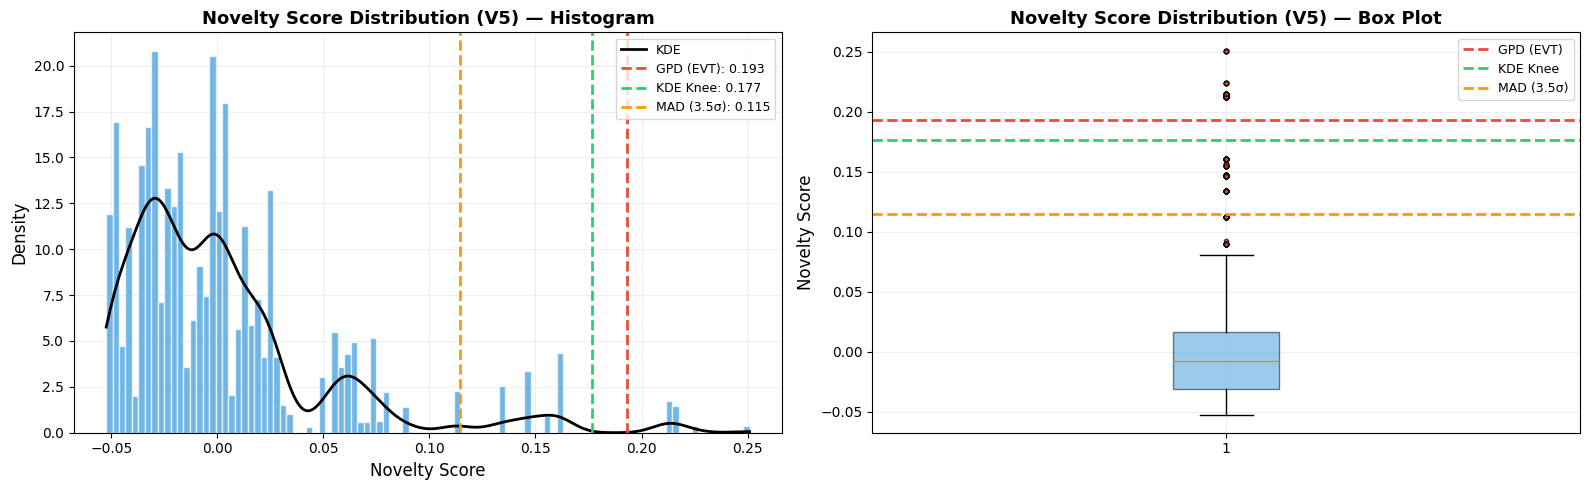

In [ ]:
# Visualize score distribution with all threshold lines
plot_score_distribution(
    novelty_scores,
    thresholds={
        'GPD (EVT)': threshold_gpd,
        'KDE Knee': threshold_kde,
        'MAD (3.5σ)': threshold_mad,
    },
    title=f'Novelty Score Distribution ({BEST_VERSION.upper()})',
    save_path=os.path.join(PLOTS_DIR, f'score_distribution_{BEST_VERSION}.png'),
)

In [ ]:
# 1. System Setup (their Cell 1) + your path overrides
# 2. Imports (their Cell 2)
# 3. Load ONLY v5 latents — skip v1/v3 entirely, you don't need them for this step
latents, filenames = load_latents(save_dir=LATENT_DIR, version='v5')

# 4. Rebuild features + rerun Isolation Forest (fast, this part never crashed)
features, info_df = build_features(latents=latents, filenames=filenames, metadata_path=METADATA_PATH)
novelty_scores = run_isolation_forest(features, n_estimators=300, max_samples='auto', random_state=42)

[Latent] Loaded 10422 vectors of dim 256
[Metadata] Loaded 172 rows from /content/drive/MyDrive/nssc2026/source_image_metadata.csv
[Metadata] Columns: ['source_image_id', 'latitude', 'longitude', 'sun_angle', 'season', 'resolution']
[Fusion] Matched 10422/10422 images to metadata
[Fusion] sun_angle range: [32.1, 85.7]
[Fusion] season encoded cyclically (sin, cos)
[Fusion] Combined feature dim: 256 (latent) + 3 (metadata) = 259
[IF] Fitting Isolation Forest (n_estimators=300)...
[IF] Score range: [-0.0525, 0.2510] (mean=0.0024, std=0.0497)


## 2.7 Save Scores & Metadata

In [ ]:
# Save all scores to CSV
scores_df = save_scores(
    scores=novelty_scores,
    filenames=filenames,
    is_anomaly=is_anomaly,
    info_df=info_df,
    save_path=os.path.join(SCORES_DIR, f'novelty_scores_{BEST_VERSION}.csv'),
    version=BEST_VERSION,
)

# Show top anomalies
print('\nTop 10 Most Anomalous Images:')
print('=' * 70)
print(scores_df.head(10).to_string(index=False))

[Scores] Saved 10422 entries → /content/outputs/scores/novelty_scores_v5.csv
[Scores] 125 flagged as anomalous

Top 10 Most Anomalous Images:
        filename  novelty_score  is_anomaly model_version source_image_id  latitude  longitude  sun_angle   season  resolution
sample_06855.jpg       0.250972        True            v5         SRC_012     -90.0        0.0  85.677016 N-autumn         0.5
sample_03073.jpg       0.250972        True            v5         SRC_012     -90.0        0.0  85.677016 N-autumn         0.5
sample_06556.jpg       0.250972        True            v5         SRC_012     -90.0        0.0  85.677016 N-autumn         0.5
sample_06495.jpg       0.250972        True            v5         SRC_012     -90.0        0.0  85.677016 N-autumn         0.5
sample_06390.jpg       0.250972        True            v5         SRC_012     -90.0        0.0  85.677016 N-autumn         0.5
sample_07583.jpg       0.250972        True            v5         SRC_012     -90.0        0.0  

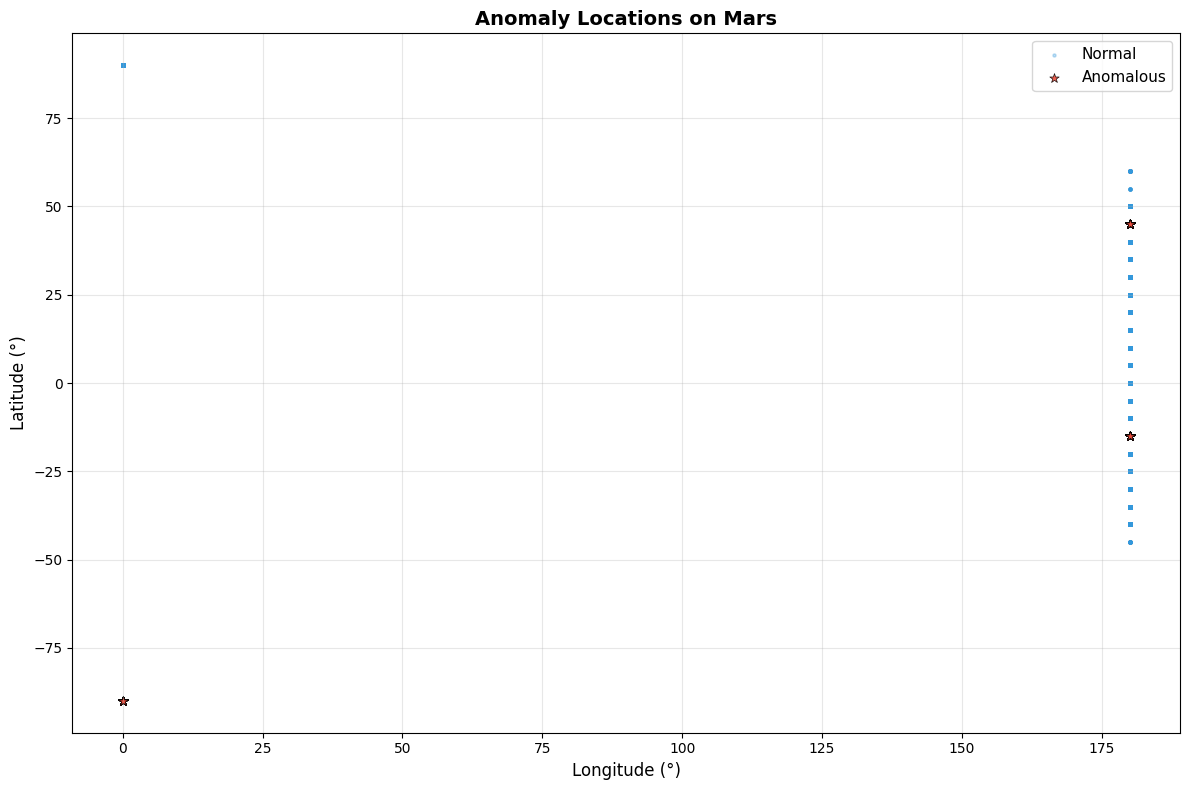


✓ Phase 2 complete. Scores saved for Phase 3.


In [ ]:
# Location analysis: if metadata is available, show geographical distribution
if 'latitude' in scores_df.columns and 'longitude' in scores_df.columns:
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Normal images
    normal = scores_df[~scores_df['is_anomaly']]
    anomalous = scores_df[scores_df['is_anomaly']]

    ax.scatter(normal['longitude'], normal['latitude'],
               c='#3498db', s=5, alpha=0.3, label='Normal')
    ax.scatter(anomalous['longitude'], anomalous['latitude'],
               c='#e74c3c', s=50, alpha=0.9, marker='*',
               edgecolors='black', linewidth=0.5, label='Anomalous')

    ax.set_xlabel('Longitude (°)', fontsize=12)
    ax.set_ylabel('Latitude (°)', fontsize=12)
    ax.set_title('Anomaly Locations on Mars', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'anomaly_locations.png'), dpi=150)
    plt.show()
else:
    print('Latitude/longitude not available in metadata.')

print('\n✓ Phase 2 complete. Scores saved for Phase 3.')